# 03. Build Quarterly Dataset for Thailand

This notebook rebuilds the Thailand macro dataset at quarterly frequency. The motivation comes from stationarity issues found in the monthly specification, where several macro variables appear I(2) due to smooth monthly dynamics and possible data construction artifacts. The output will be used in the next notebook for quarterly stationarity diagnostics.

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

## Load monthly data
Read the processed monthly Thailand macro dataset, ensure datetime index, and inspect basic properties.

In [15]:
# Load monthly data
monthly_path = '../../data/processed/THA_model_ready.csv'
df = pd.read_csv(monthly_path, parse_dates=['date'], index_col='date')
# Ensure index is datetime and sorted
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Date range:', df.index.min(), 'to', df.index.max())
print('Missing values:', df.isnull().sum())
print('First 5 rows:')
print(df.head())
# Try to infer frequency
freq = pd.infer_freq(df.index)
print('Inferred frequency:', freq)

Shape: (217, 5)
Columns: ['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']
Date range: 2006-01-01 00:00:00 to 2024-01-01 00:00:00
Missing values: ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64
First 5 rows:
              ln_WTI     ln_GDP    ln_CPI  Interest     ln_FX
date                                                         
2006-01-01  4.181821  26.124854  4.506294  6.273807  3.634476
2006-02-01  4.121166  26.140212  4.508160  6.254871  3.627048
2006-03-01  4.138126  26.155337  4.510023  6.235934  3.619566
2006-04-01  4.240516  26.170238  4.511882  6.216998  3.612026
2006-05-01  4.260482  26.184919  4.513738  6.198061  3.604430
Inferred frequency: MS


## Quarterly Aggregation Choices
The current dataset is already transformed to logs for `ln_WTI`, `ln_GDP`, `ln_CPI`, and `ln_FX`.

- **ln_WTI**, **ln_CPI**, **ln_FX**: quarterly mean of logged monthly values.
  This is practical for a log-transformed dataset, but it is only an approximation to first averaging the underlying level variables within a quarter and then taking logs.
  (Because $\log(\overline{X}) \neq \overline{\log(X)}$ in general.)
- **ln_GDP**: end-of-quarter (`last`) value instead of mean.
  Monthly GDP in macro datasets is often interpolated/smoothed from lower-frequency sources, so averaging monthly logged GDP can over-smooth and blur quarter-end conditions.
  Using `last` keeps a clear quarter-end signal and is more defensible for this constructed monthly GDP series.
- **Interest**: Quarterly average interest rate.

These choices are kept simple and transparent because this notebook's role is dataset construction, not model estimation.

In [16]:
# Build quarterly aggregation pipeline
agg_rules = {
    'ln_WTI': 'mean',
    'ln_GDP': 'last',
    'ln_CPI': 'mean',
    'Interest': 'mean',
    'ln_FX': 'mean'
}
# Resample to calendar quarter end
df_q = df.resample('QE').agg(agg_rules)
# Drop rows where all values are missing
df_q = df_q.dropna(how='all')
print('Quarterly shape:', df_q.shape)
print('Quarterly date range:', df_q.index.min(), 'to', df_q.index.max())
print('Quarterly head:')
print(df_q.head())

Quarterly shape: (73, 5)
Quarterly date range: 2006-03-31 00:00:00 to 2024-03-31 00:00:00
Quarterly head:
              ln_WTI     ln_GDP    ln_CPI  Interest     ln_FX
date                                                         
2006-03-31  4.147038  26.155337  4.508159  6.254871  3.627030
2006-06-30  4.254329  26.199388  4.513737  6.198061  3.604410
2006-09-30  4.252125  26.241580  4.519283  6.141251  3.581267
2006-12-31  4.093711  26.282063  4.524800  6.084442  3.557576
2007-03-31  4.060750  26.313068  4.533001  6.027845  3.538570


## Validation Checks
- Missing values by column
- Number of observations before vs after conversion
- Expected number of quarters
- Duplicate index check
- Monotonicity and order
- Summary statistics for both monthly and quarterly data

In [ ]:
# Validation
print('Missing values in quarterly data:', df_q.isnull().sum())
print('Monthly obs:', len(df))
print('Quarterly obs:', len(df_q))
first_q = df.index.min().to_period('Q')
last_q = df.index.max().to_period('Q')
expected_quarters = len(pd.period_range(first_q, last_q, freq='Q'))
print('Quarterly span from monthly index:', first_q, 'to', last_q)
print('Expected quarters (from actual covered periods):', expected_quarters)
print('Duplicate quarters:', df_q.index.duplicated().sum())
print('Quarterly index monotonic:', df_q.index.is_monotonic_increasing)
print('Monthly data summary:')
print(df.describe())
print('Quarterly data summary:')
print(df_q.describe())

Missing values in quarterly data: ln_WTI      0
ln_GDP      0
ln_CPI      0
Interest    0
ln_FX       0
dtype: int64
Monthly obs: 217
Quarterly obs: 73
Expected quarters: 76
Duplicate quarters: 0
Quarterly index monotonic: True
Monthly data summary:
           ln_WTI      ln_GDP      ln_CPI    Interest       ln_FX
count  217.000000  217.000000  217.000000  217.000000  217.000000
mean     4.231815   26.726899    4.678495    4.563532    3.497605
std      0.330147    0.238056    0.075335    0.828061    0.051493
min      2.806242   26.124854    4.506294    3.060000    3.417456
25%      4.003798   26.598089    4.624035    4.125833    3.446401
50%      4.270790   26.746088    4.706031    4.534228    3.504380
75%      4.493400   26.943559    4.724459    5.077546    3.541486
max      4.896944   27.022172    4.812175    6.273807    3.634476
Quarterly data summary:
          ln_WTI     ln_GDP     ln_CPI   Interest      ln_FX
count  73.000000  73.000000  73.000000  73.000000  73.000000
mean    4.

## Comparison Plots: Monthly vs Quarterly
Each plot overlays the monthly and quarterly series for visual validation.

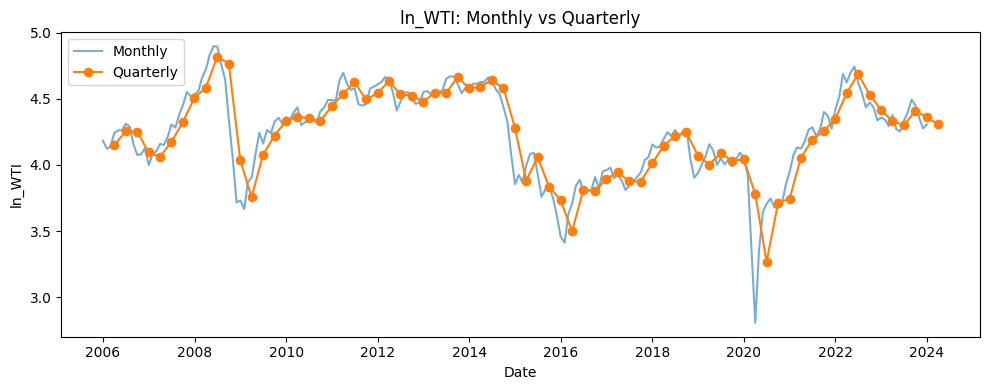

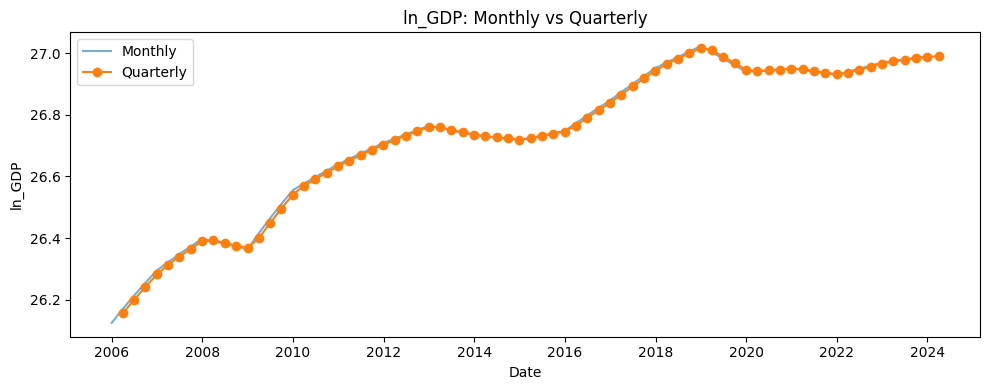

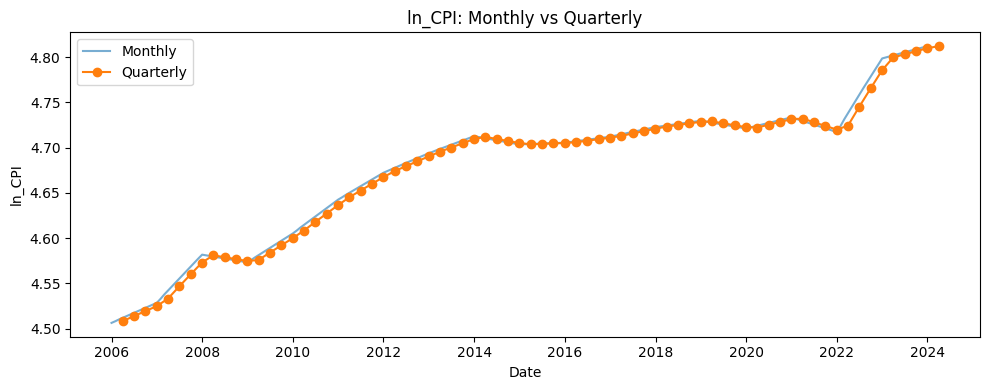

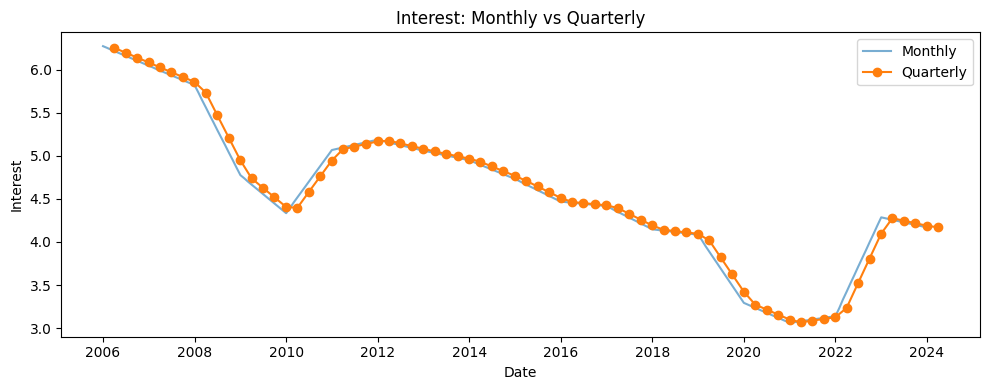

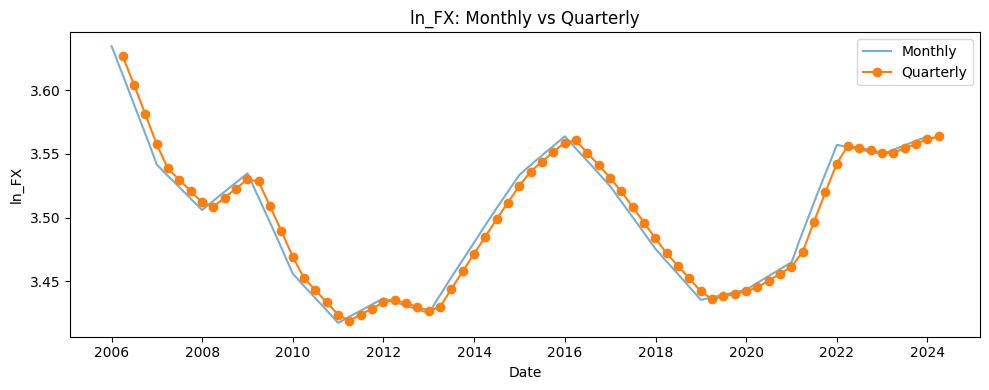

In [18]:
# Comparison plots
for col in df_q.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df.index, df[col], label='Monthly', alpha=0.6)
    plt.plot(df_q.index, df_q[col], marker='o', linestyle='-', label='Quarterly', color='tab:orange')
    plt.title(f'{col}: Monthly vs Quarterly')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation
Quarterly aggregation smooths short-run fluctuations and may be more appropriate for macro variables such as GDP, CPI, interest rate, and exchange rate. This dataset will now be used for a fresh round of stationarity diagnostics at quarterly frequency.

In [19]:
# Save the quarterly dataset
quarterly_path1 = '../../data/processed/THA_model_ready_quarterly.csv'
quarterly_path2 = '../../outputs/THA/THA_model_ready_quarterly_preview.csv'
df_q.to_csv(quarterly_path1, index=True)
df_q.to_csv(quarterly_path2, index=True)
print('Saved to:', quarterly_path1)
print('Saved to:', quarterly_path2)

Saved to: ../../data/processed/THA_model_ready_quarterly.csv
Saved to: ../../outputs/THA/THA_model_ready_quarterly_preview.csv


## Conclusion
The quarterly Thailand dataset has now been prepared as a more defensible basis for macroeconomic time-series analysis. The next step is to re-run stationarity diagnostics at quarterly frequency before selecting the final model specification.